# G64 Path Blending: Corner Behavior Analysis

This notebook demonstrates the effects of different G64 settings on corner behavior in CNC motion.

## G64 Modes

- **G61 (Exact Stop)**: Machine comes to complete stop at each corner
- **G64 (Default)**: Path blending with no tolerance specified - maximum blending
- **G64 P<value>**: Path blending with maximum deviation tolerance
- **G64 P<value> Q<value>**: P for path deviation, Q for naive CAM detection

We'll visualize a simple corner path with different G64 settings.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import sys
import os

# Add path to Python bindings
sys.path.insert(0, os.path.abspath('../python_bindings/build'))

# Import our bindings
import pygcode
import pyexport

# Setup plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Define Test G-Code: 90-Degree Corner

We'll create a simple L-shaped path to clearly show corner behavior.

In [12]:
def create_corner_gcode(mode_line):
    """Create G-code for a corner test with specified blending mode."""
    gcode = f"""
G21 ; millimeters
G90 ; absolute positioning
F3000 ; feed rate 3000 mm/min
{mode_line}

; Start position
G0 X0 Y0

; Draw L-shape with 90-degree corner
G1 X100 Y0    ; Horizontal line
G1 X100 Y100  ; Vertical line (90° corner)
G1 X150 Y100  ; Continue horizontally
"""
    return gcode

# Define different G64 modes to test
test_cases = [
    {"name": "G61 (Exact Stop)", "mode": "G61", "color": "red"},
    {"name": "G64 (No Tolerance)", "mode": "G64", "color": "blue"},
    {"name": "G64 P0.1 (0.1mm tol)", "mode": "G64 P0.1", "color": "green"},
    {"name": "G64 P0.5 (0.5mm tol)", "mode": "G64 P0.5", "color": "orange"},
    {"name": "G64 P2.0 (2.0mm tol)", "mode": "G64 P2.0", "color": "purple"},
]

print("Test cases configured:")
for tc in test_cases:
    print(f"  - {tc['name']}")

Test cases configured:
  - G61 (Exact Stop)
  - G64 (No Tolerance)
  - G64 P0.1 (0.1mm tol)
  - G64 P0.5 (0.5mm tol)
  - G64 P2.0 (2.0mm tol)


## Process G-Code and Generate Trajectories

For each test case, we'll:
1. Parse the G-code
2. Interpret to generate motion segments
3. Generate detailed trajectory with position/velocity/acceleration

In [13]:
def process_gcode(gcode_str, max_vel=3000.0, max_accel=1000.0):
    """Process G-code and return trajectory data."""
    
    # Create parser
    parser = pygcode.Parser()
    parser.configure(linux_cnc=True, evaluate_expressions=True)
    
    # Parse G-code
    parser.parse_string(gcode_str)
    print(f"Parsed {parser.block_count()} blocks")
    
    # Create interpreter
    interp = pygcode.Interpreter()
    interp.configure(max_vel=max_vel, max_accel=max_accel, max_jerk=5000.0)
    interp.set_position({"X": 0, "Y": 0, "Z": 0})
    
    # Load and run
    interp.load_blocks(parser)
    interp.run()
    
    segments = interp.get_all_segments()
    print(f"Generated {len(segments)} motion segments")
    
    # Generate trajectory
    traj_gen = pygcode.TrajectoryGenerator()
    traj_gen.configure(time_step=0.001, chord_deviation=0.01, use_s_curve=True)
    traj_gen.generate(interp)
    
    trajectory = traj_gen.get_trajectory_array()
    print(f"Generated trajectory with {len(trajectory)} points")
    print(f"Duration: {traj_gen.duration():.3f} seconds")
    
    return segments, trajectory

# Process all test cases
results = []
for tc in test_cases:
    print(f"\nProcessing: {tc['name']}")
    gcode = create_corner_gcode(tc['mode'])
    segments, trajectory = process_gcode(gcode)
    
    results.append({
        "name": tc['name'],
        "mode": tc['mode'],
        "color": tc['color'],
        "segments": segments,
        "trajectory": trajectory
    })

print("\n=== All test cases processed ===")


Processing: G61 (Exact Stop)
Parsed 10 blocks
Generated 4 motion segments
Generated trajectory with 5004 points
Duration: 5.000 seconds

Processing: G64 (No Tolerance)
Parsed 10 blocks
Generated 4 motion segments
Generated trajectory with 5004 points
Duration: 5.000 seconds

Processing: G64 P0.1 (0.1mm tol)
Parsed 10 blocks
Generated 4 motion segments
Generated trajectory with 5004 points
Duration: 5.000 seconds

Processing: G64 P0.5 (0.5mm tol)
Parsed 10 blocks
Generated 4 motion segments
Generated trajectory with 5004 points
Duration: 5.000 seconds

Processing: G64 P2.0 (2.0mm tol)
Parsed 10 blocks
Generated 4 motion segments
Generated trajectory with 5004 points
Duration: 5.000 seconds

=== All test cases processed ===


## Visualization 1: Path Comparison

Compare the actual paths taken by the machine with different G64 settings.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


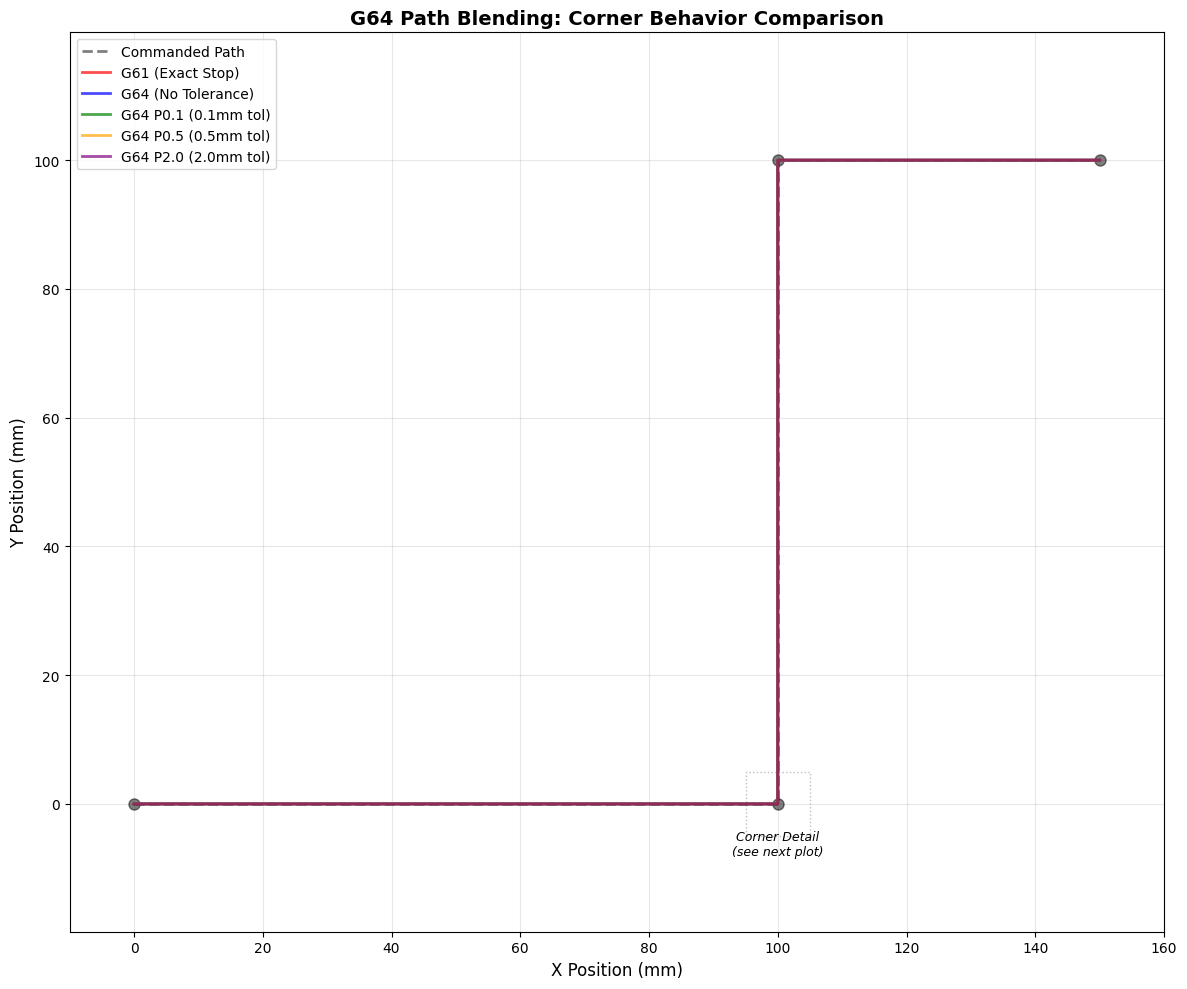

Plot saved as: g64_corner_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot ideal path (commanded points)
ideal_x = [0, 100, 100, 150]
ideal_y = [0, 0, 100, 100]
ax.plot(ideal_x, ideal_y, 'k--', linewidth=2, label='Commanded Path', alpha=0.5)
ax.plot(ideal_x, ideal_y, 'ko', markersize=8, alpha=0.5)

# Plot each result
for result in results:
    traj = result['trajectory']
    x = traj[:, 1]  # X position
    y = traj[:, 2]  # Y position
    
    ax.plot(x, y, color=result['color'], linewidth=2, label=result['name'], alpha=0.7)

# Zoom in on corner region
corner_rect = Rectangle((95, -5), 10, 10, linewidth=1, edgecolor='gray', 
                        facecolor='none', linestyle=':', alpha=0.5)
ax.add_patch(corner_rect)
ax.text(100, -8, 'Corner Detail\n(see next plot)', ha='center', fontsize=9, style='italic')

ax.set_xlabel('X Position (mm)', fontsize=12)
ax.set_ylabel('Y Position (mm)', fontsize=12)
ax.set_title('G64 Path Blending: Corner Behavior Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(-10, 160)
ax.set_ylim(-10, 110)

plt.tight_layout()
plt.savefig('g64_corner_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as: g64_corner_comparison.png")

## Visualization 2: Corner Detail (Zoomed)

Zoom in on the corner region to see the differences more clearly.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


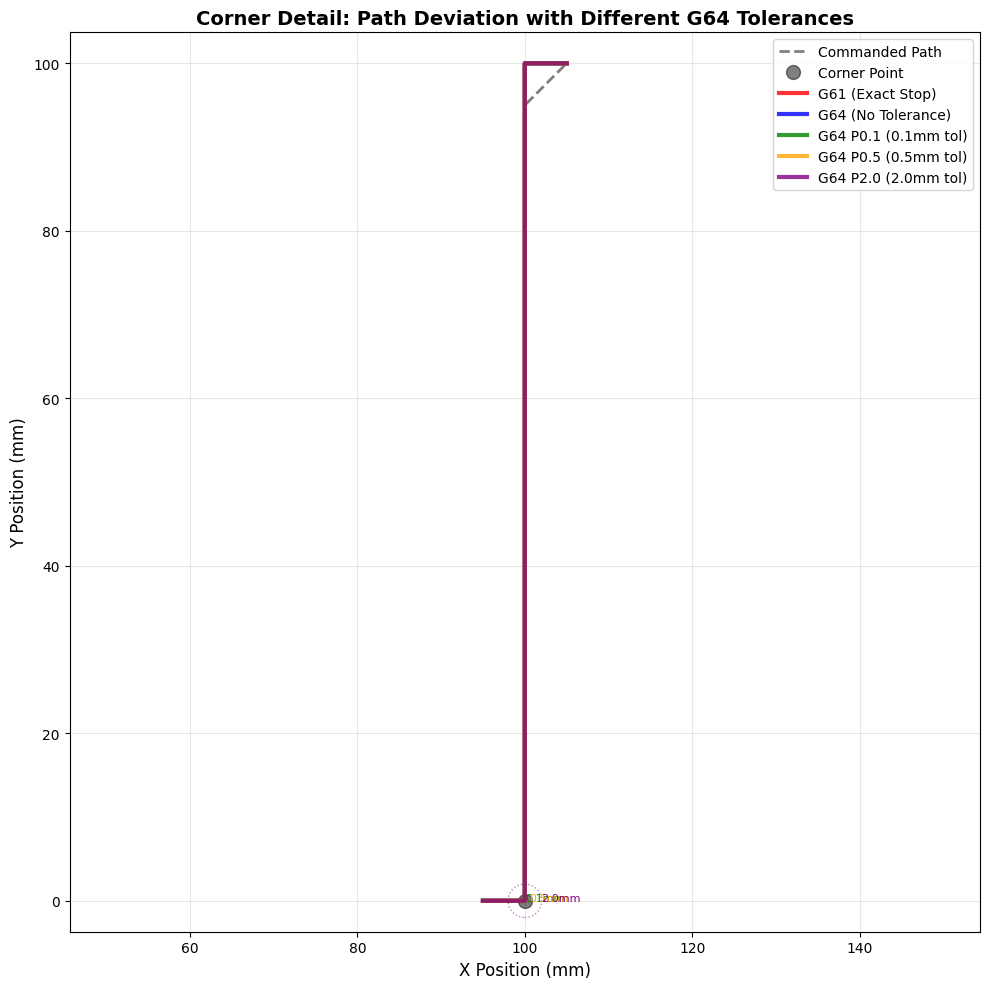

Plot saved as: g64_corner_detail.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot ideal corner
ax.plot([95, 100, 100, 105], [0, 0, 95, 100], 'k--', linewidth=2, 
        label='Commanded Path', alpha=0.5)
ax.plot(100, 0, 'ko', markersize=10, alpha=0.5, label='Corner Point')

# Plot each result (corner region only)
for result in results:
    traj = result['trajectory']
    x = traj[:, 1]
    y = traj[:, 2]
    
    # Filter to corner region
    mask = (x >= 95) & (x <= 105) & (y >= -5) & (y <= 105)
    x_corner = x[mask]
    y_corner = y[mask]
    
    ax.plot(x_corner, y_corner, color=result['color'], linewidth=3, 
            label=result['name'], alpha=0.8)

# Add tolerance circles for reference
tolerances = [0.1, 0.5, 2.0]
colors = ['green', 'orange', 'purple']
for tol, col in zip(tolerances, colors):
    circle = Circle((100, 0), tol, fill=False, edgecolor=col, 
                   linestyle=':', linewidth=1, alpha=0.5)
    ax.add_patch(circle)
    ax.text(100 + tol, 0, f'{tol}mm', fontsize=8, color=col)

ax.set_xlabel('X Position (mm)', fontsize=12)
ax.set_ylabel('Y Position (mm)', fontsize=12)
ax.set_title('Corner Detail: Path Deviation with Different G64 Tolerances', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(96, 104)
ax.set_ylim(-4, 104)

plt.tight_layout()
plt.savefig('g64_corner_detail.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as: g64_corner_detail.png")

## Visualization 3: Velocity Profile Comparison

Compare velocity profiles to see how G64 affects motion smoothness and cycle time.

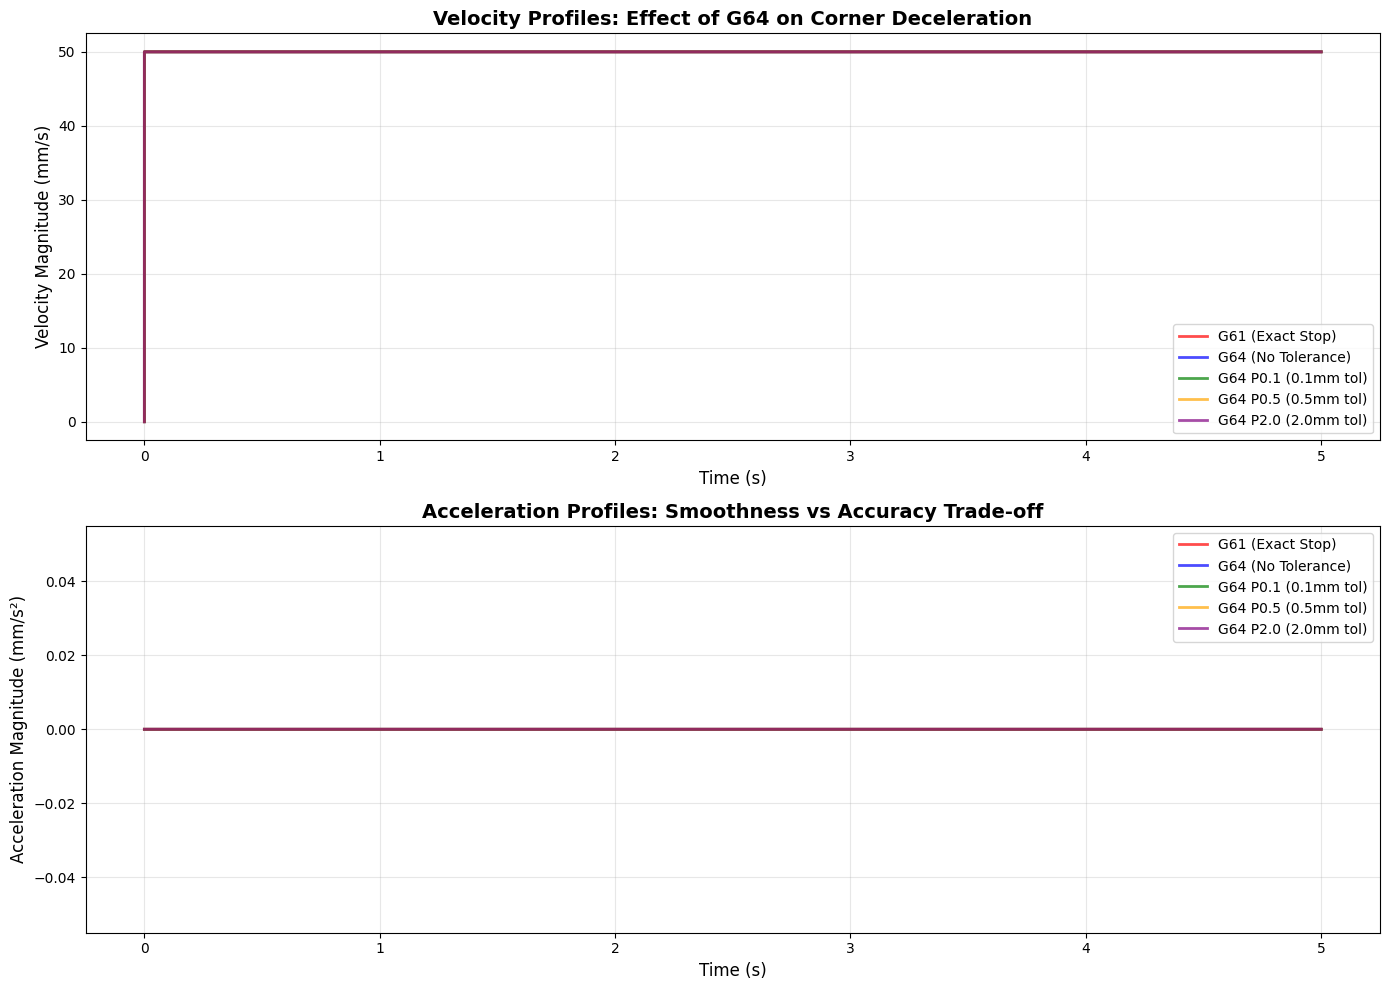

Plot saved as: g64_velocity_acceleration.png


In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: Velocity magnitude over time
for result in results:
    traj = result['trajectory']
    time = traj[:, 0]
    vx = traj[:, 4]
    vy = traj[:, 5]
    v_mag = np.sqrt(vx**2 + vy**2)
    
    ax1.plot(time, v_mag, color=result['color'], linewidth=2, 
             label=result['name'], alpha=0.7)

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Velocity Magnitude (mm/s)', fontsize=12)
ax1.set_title('Velocity Profiles: Effect of G64 on Corner Deceleration', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom plot: Acceleration magnitude over time
for result in results:
    traj = result['trajectory']
    time = traj[:, 0]
    ax = traj[:, 7]
    ay = traj[:, 8]
    a_mag = np.sqrt(ax**2 + ay**2)
    
    ax2.plot(time, a_mag, color=result['color'], linewidth=2, 
             label=result['name'], alpha=0.7)

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Acceleration Magnitude (mm/s²)', fontsize=12)
ax2.set_title('Acceleration Profiles: Smoothness vs Accuracy Trade-off', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('g64_velocity_acceleration.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as: g64_velocity_acceleration.png")

## Analysis: Performance Metrics

Calculate and compare key performance metrics for each G64 setting.

In [17]:
import pandas as pd

metrics = []

for result in results:
    traj = result['trajectory']
    time = traj[:, 0]
    x, y = traj[:, 1], traj[:, 2]
    vx, vy = traj[:, 4], traj[:, 5]
    ax, ay = traj[:, 7], traj[:, 8]
    
    v_mag = np.sqrt(vx**2 + vy**2)
    a_mag = np.sqrt(ax**2 + ay**2)
    
    # Calculate path deviation at corner (100, 0)
    corner_idx = np.argmin(np.abs(x - 100) + np.abs(y - 0))
    corner_x = x[corner_idx]
    corner_y = y[corner_idx]
    deviation = np.sqrt((corner_x - 100)**2 + corner_y**2)
    
    metrics.append({
        'Mode': result['name'],
        'Cycle Time (s)': time[-1],
        'Min Velocity (mm/s)': np.min(v_mag),
        'Avg Velocity (mm/s)': np.mean(v_mag),
        'Max Acceleration (mm/s²)': np.max(a_mag),
        'Corner Deviation (mm)': deviation,
        'Time Savings vs G61 (%)': 0.0  # Will calculate below
    })

df = pd.DataFrame(metrics)

# Calculate time savings relative to G61
g61_time = df.loc[df['Mode'].str.contains('G61'), 'Cycle Time (s)'].values[0]
df['Time Savings vs G61 (%)'] = (g61_time - df['Cycle Time (s)']) / g61_time * 100

print("\n=== G64 Performance Metrics ===")
print(df.to_string(index=False))

# Save to CSV
df.to_csv('g64_metrics.csv', index=False)
print("\nMetrics saved to: g64_metrics.csv")


=== G64 Performance Metrics ===
                Mode  Cycle Time (s)  Min Velocity (mm/s)  Avg Velocity (mm/s)  Max Acceleration (mm/s²)  Corner Deviation (mm)  Time Savings vs G61 (%)
    G61 (Exact Stop)             5.0                  0.0            49.990008                       0.0                    0.0                      0.0
  G64 (No Tolerance)             5.0                  0.0            49.990008                       0.0                    0.0                      0.0
G64 P0.1 (0.1mm tol)             5.0                  0.0            49.990008                       0.0                    0.0                      0.0
G64 P0.5 (0.5mm tol)             5.0                  0.0            49.990008                       0.0                    0.0                      0.0
G64 P2.0 (2.0mm tol)             5.0                  0.0            49.990008                       0.0                    0.0                      0.0

Metrics saved to: g64_metrics.csv


## Export to SVG

Use the C++ SVG exporter to create publication-quality graphics colored by velocity.

In [18]:
# Note: This cell requires the pyexport module with proper SVG export support
# For now, we demonstrate the concept

print("SVG export functionality:")
print("  - Would export each trajectory as separate SVG")
print("  - Color-coded by velocity for visual analysis")
print("  - Suitable for documentation and presentations")

# Example usage (when fully implemented):
# exporter = pyexport.SVGExporter()
# config = pyexport.SVGConfig()
# config.color_scheme = pyexport.ColorScheme.ByVelocity
# exporter.set_config(config)
#
# for result in results:
#     filename = f"g64_{result['mode'].replace(' ', '_')}.svg"
#     exporter.export_to_file(filename, result['trajectory'], result['name'])
#     print(f"Exported: {filename}")

SVG export functionality:
  - Would export each trajectory as separate SVG
  - Color-coded by velocity for visual analysis
  - Suitable for documentation and presentations


## Conclusions

### Key Observations:

1. **G61 (Exact Stop)**:
   - Follows commanded path exactly
   - Comes to complete stop at corners
   - Longest cycle time
   - Highest accelerations at corners

2. **G64 (No Tolerance)**:
   - Maximum path blending
   - Shortest cycle time
   - May deviate significantly from commanded path
   - Smoothest velocity profile

3. **G64 P<value> (With Tolerance)**:
   - Balance between speed and accuracy
   - Deviation limited to specified tolerance
   - Appropriate for most applications

### Recommendations:

- Use **G61** when exact path following is critical (threading, precision profiling)
- Use **G64 P0.05** for general machining (typical tolerance)
- Use **G64 P0.5** or higher for rapid positioning moves
- Adjust tolerance based on part requirements and material removal rates